# Notebook for plotting surface change in the Cuk 2021 scenarios: Figure 7, 8 and S1
## Preamble
### Load packages required

In [1]:
#SJL 3/2023
#Script to plot a comparison of the the change in surface length for example tidal evolution scenarios

###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

from scipy.signal import savgol_filter

#package to use wildcards 
import fnmatch

import csv

from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import griddata

#plotting packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec


cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")
    
#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')

/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

### Define constants

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

### Define parameters and location of data

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
#info for HERCULES arrays
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'
    
#directory for length change data
data_dir='Data/Cuk_et_al_2021_high_obliquity'

#directory for additional data needed for 
dir_additional_data='../Lock_2026_SI_additional_data'

#number of contor points
Ncont=100 

#Earth's moment of inertia used to convert to AM
C_Earth=0.3304


### Read in planetary structure calculations

In [4]:
########################################################################################
########################################################################################
########################################################################################
#MAIN

########################################################################################
#read in the database

Hdatabase=HERCULES_random_planet_database_1D()
Hdatabase.make_array(Hdir,Hname)
Hdatabase.initialize_interpolation([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],\
                                   [0,0,[],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]], flag_extrap=1)

#extract the latitudes for each Mu point
Nmu=Hdatabase.parr[0].Nmu
lat=np.arccos(Hdatabase.parr[0].layers[0].mu)*180/np.pi


Earth_correct_params_S3.20c
	 Earth_correct_params_S3.20c_AM3.3125
	 Earth_correct_params_S3.20c_AM3.30625
	 Earth_correct_params_S3.20c_AM3.325


## Figures 7 and 8

### Load in data

In [5]:
#Figure 3 or 7 data
dir=data_dir+'/rev9_for_simon'
dirnames_const=['rev9a','rev9b', 'rev9c','rev9e2']

Nruns_const=np.size(dirnames_const)

#########################
#read in the constant path
Ctime_const=[]
Ctime_high_const=[]
Ca_const=[]
Cob_const=[]
Comg_const=[]
CL_const=[]
Ce_const=[]
Ci_const=[]

for k in np.arange(np.size(dirnames_const)):
    
    ###Semi-major axis, e, i
    Cuk_f=open(dir+'/'+dirnames_const[k]+'/moon101.out', 'r')

    #extract the lines and strip them of any new lines etc.
    reader = csv.reader(Cuk_f, delimiter=" ", skipinitialspace=True)
    temp = list(reader)

    for i in np.arange(len(temp)):
        
        if (np.size(temp[i])>3):
            
            Ctime_const.append(temp[i][0]) #time
            Ca_const.append(temp[i][1]) #semi-major axis
            Ce_const.append(temp[i][2]) #eccentricity
            Ci_const.append(temp[i][3])
        

    ###obliquity
    Cuk_f=open(dir+'/'+dirnames_const[k]+'/pole.out', 'r')

    #extract the lines and strip them of any new lines etc.
    reader = csv.reader(Cuk_f, delimiter=" ", skipinitialspace=True)
    temp = list(reader)

    for i in np.arange(len(temp)):
        if np.size(temp[i])>4:
            Cob_const.append(temp[i][1]) #obliquity
            Comg_const.append(temp[i][3]) #rotation rate
            


#convert to useful type and unit
Ctime_const=np.asarray(Ctime_const, dtype=np.float64)
Ca_const=np.asarray(Ca_const, dtype=np.float64)
Cob_const=np.asarray(Cob_const, dtype=np.float64)
Ce_const=np.asarray(Ce_const, dtype=np.float64)
Ci_const=np.asarray(Ci_const, dtype=np.float64)
Comg_const=np.asarray(Comg_const, dtype=np.float64)/const.year
CL_const=Comg_const*C_Earth*MEarth*(REarth**2)

#remove any repeat values
temp=(Ctime_const[1:]-Ctime_const[:-1])
ind=np.where(temp==0.0)[0]
Ctime_const=np.delete(Ctime_const,ind+1)
Ca_const=np.delete(Ca_const,ind+1)
Cob_const=np.delete(Cob_const,ind+1)
Ce_const=np.delete(Ce_const,ind+1)
Ci_const=np.delete(Ci_const,ind+1)
Comg_const=np.delete(Comg_const,ind+1)
CL_const=np.delete(CL_const,ind+1)

#change names to be consistent with rest of program
Ctime=Ctime_const
Ca=Ca_const
Cob=Cob_const
Ce=Ce_const
Ci=Ci_const

Comg=Comg_const
CL=CL_const

    

print('done')

done


In [6]:
import numpy as np
import h5py

# --------------------------------------------------
# User inputs
# --------------------------------------------------
hdf5_file = dir_additional_data+"/Cuk21_surf_change_CukFig7_delta.h5"

# --------------------------------------------------
# Open HDF5 file
# --------------------------------------------------
with h5py.File(hdf5_file, "r") as h5:

    Nmu = h5.attrs["Nmu"]
    Nt  = h5.attrs["Nt"]
    Ntmax     = None # optional limit on number of timesteps
    if Ntmax is not None:
        Nt = min(Nt, Ntmax)

    print(f"Nmu = {Nmu}, Nt = {Nt}")

    # --------------------------------------------------
    # Load time and dL_dt
    # --------------------------------------------------
    steps = np.arange(Nt)
    time  = h5["time"][:Nt]
    dLdt = h5["dL_dt"][:Nt]

    # --------------------------------------------------
    # Precompute cumulative sums of delta fields
    # --------------------------------------------------
    names = ["dl_lat", "dl_lon", "dA",
             "ddl_lat_dL", "ddl_lon_dL", "ddA_dL"]

    cum_delta = {}
    for name in names:
        cum_delta[name] = np.cumsum(h5["delta"][name][:Nt, :], axis=0)

    # --------------------------------------------------
    # Reconstruct full arrays (similar to your binary reshaping)
    # --------------------------------------------------
    dl_lat      = cum_delta["dl_lat"]
    dl_lon      = cum_delta["dl_lon"]
    dA          = cum_delta["dA"]
    ddl_lat_dL  = cum_delta["ddl_lat_dL"]
    ddl_lon_dL  = cum_delta["ddl_lon_dL"]
    ddA_dL      = cum_delta["ddA_dL"]

    # Compute _dt fields from delta and dL_dt
    ddl_lat_dt  = ddl_lat_dL * dLdt[:, np.newaxis]
    ddl_lon_dt  = ddl_lon_dL * dLdt[:, np.newaxis]
    ddA_dt      = ddA_dL * dLdt[:, np.newaxis]


print("Data successfully loaded from HDF5!")


Nmu = 1000, Nt = 136382
Data successfully loaded from HDF5!


In [7]:
# #read in the change of length data
# data_file=data_dir+'/Cuk21_surf_change_CukFig7.bin'

# dataf = open(data_file, "rb")

# #read in the number of mu surface points
# Nmu=struct.unpack('i', dataf.read(4))[0]

# #now read in the rest of the file as one massive array
# data = np.fromfile(dataf, dtype=np.float64, count=-1)
# dataf.close()

# #work out how many time steps we have
# ndata_per_step=9*Nmu+2
# temp=np.size(data)*1.0/(1.0*ndata_per_step)
# if abs(temp-int(temp))<(1E-12):
#     Ntstep=int(temp)
# else:
#     print("ERROR IN READ",'\n',"Not complete number of steps or incorrect number of print params",'\n',"EXITING")

# #reshape array so that each row is a timestep
# data=data.reshape(Ntstep,ndata_per_step)

# steps=data[:,0].astype(int)
# time=data[:,1]
# dl_lat=data[:,2:ndata_per_step:9]
# dl_lon=data[:,3:ndata_per_step:9]
# dA=data[:,4:ndata_per_step:9]
# ddl_lat_dL=data[:,5:ndata_per_step:9]
# ddl_lon_dL=data[:,6:ndata_per_step:9]
# ddA_dL=data[:,7:ndata_per_step:9]
# ddl_lat_dt=data[:,8:ndata_per_step:9]
# ddl_lon_dt=data[:,9:ndata_per_step:9]
# ddA_dt=data[:,10:ndata_per_step:9]

# dLdt=gradient2(time,CL[steps])

# print('end')


### Plot Figure 7

done


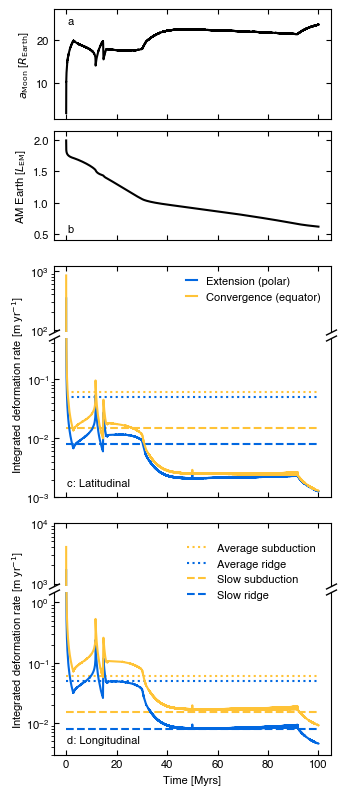

In [8]:
#plot the maximum and minimum deformation rates as a function of time
#Figure 7 or S1

#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure7.pdf')
mpl.pyplot.close(fig)

#Now make the real figure
yrange=np.asarray([[[0.91E2,1.2E3],[1E-3,0.49]],
            [[0.905E3,1E4],[3E-3,1.5]]])

hratio=np.empty(2)
for i in np.arange(2):
    hratio[i]=(np.log10(yrange[i,0,1])-np.log10(yrange[i,0,0]))/(np.log10(yrange[i,1,1])-np.log10(yrange[i,1,0]))

#initialise the figure
fig = plt.figure(figsize=(3.5,8.0))

gs0 = gridspec.GridSpec(3, 1,
                        width_ratios=[1],
                        height_ratios=[1,1,1],
                        )

gs000 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=gs0[0],
                                        height_ratios=[1,1],
#                                         hspace=0.05,
#                                         wspace=0.05
                                        )

gs00 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=gs0[1],
                                        height_ratios=[hratio[0],1],
                                        hspace=0.05,
                                        wspace=0.05
                                        )
gs01 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=gs0[2],
                                        height_ratios=[hratio[1],1],
                                        hspace=0.05,
                                        wspace=0.05
                                        )

ax=[[],[],[]]


ax[0].append(plt.subplot(gs00[0]))
ax[0].append(plt.subplot(gs00[1], sharex=ax[0][0]))

ax[1].append(plt.subplot(gs01[0], sharex=ax[0][0]))
ax[1].append(plt.subplot(gs01[1], sharex=ax[0][0]))

ax[2].append(plt.subplot(gs000[0], sharex=ax[0][0]))
ax[2].append(plt.subplot(gs000[1], sharex=ax[0][0]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)

col=cmaps.parula([0.15,0.85])


ax[2][0].plot(Ctime/1E6, Ca, 'k-', linewidth=1.5)
ax[2][1].plot(Ctime/1E6, CL/LEM, 'k-', linewidth=1.5)
ax[2][0].set_ylim([2,27])
ax[2][1].set_ylim([0.4,2.15])


ddl_lat_dt_max=np.zeros(np.size(time))*np.nan
ddl_lat_dt_min=np.zeros(np.size(time))*np.nan

ddl_lon_dt_max=np.zeros(np.size(time))*np.nan
ddl_lon_dt_min=np.zeros(np.size(time))*np.nan

ind_max=np.size(time)-1
ind_min=0#np.where(time>1E5)[0][0]
for i in np.arange(ind_min,ind_max):
    #longitudinal is easy. Accomodated around minor circle
    ddl_lon_dt_max[i]=np.amax(ddl_lon_dt[i,:])*2*np.pi
    ddl_lon_dt_min[i]=np.amin(ddl_lon_dt[i,:])*2*np.pi
    
    
    #latitudinal is harder. Need to integrate over surface
    temp=np.where(ddl_lat_dt[i,:]<0)[0][-1]
    
    #print(lat[0:temp])
    ddl_lat_dt_min[i]=2*integrate.trapezoid(ddl_lat_dt[i,0:temp]*np.pi/180.0,90.0-lat[0:temp])
    ddl_lat_dt_max[i]=integrate.trapezoid(ddl_lat_dt[i,(temp+1):]*np.pi/180.0,90.0-lat[(temp+1):])

ax[0][1].plot([0,time[ind_max]/1E6],[8E-3,8E-3],'--', color=col[0],linewidth=1.5) #slow mid ocean ridge
ax[0][1].plot([0,time[ind_max]/1E6],[15E-3,15E-3],'--', color=col[1],linewidth=1.5) #slow subduction
ax[0][1].plot([0,time[ind_max]/1E6],[50E-3,50E-3],':', color=col[0],linewidth=1.5) #average mid-ocean ridge
ax[0][1].plot([0,time[ind_max]/1E6],[60E-3,60E-3],':', color=col[1],linewidth=1.5) #avererage subduction


ax[1][1].plot([0,time[ind_max]/1E6],[60E-3,60E-3],':', color=col[1],linewidth=1.5, label='Average subduction') #avererage subduction
ax[1][1].plot([0,time[ind_max]/1E6],[50E-3,50E-3],':', color=col[0],linewidth=1.5, label='Average ridge') #average mid-ocean ridge
ax[1][1].plot([0,time[ind_max]/1E6],[15E-3,15E-3],'--', color=col[1],linewidth=1.5, label='Slow subduction') #slow subduction
ax[1][1].plot([0,time[ind_max]/1E6],[8E-3,8E-3],'--', color=col[0],linewidth=1.5, label='Slow ridge') #slow mid ocean ridge

    
ax[0][0].plot(time/1E6, np.absolute(ddl_lat_dt_max),'-', color=col[0],linewidth=1.5,label='Extension (polar)')
ax[0][0].plot(time/1E6, np.absolute(ddl_lat_dt_min),'-', color=col[1],linewidth=1.5,label='Convergence (equator)')
ax[0][1].plot(time/1E6, np.absolute(ddl_lat_dt_max),'-', color=col[0],linewidth=1.5)
ax[0][1].plot(time/1E6, np.absolute(ddl_lat_dt_min),'-', color=col[1],linewidth=1.5)


ax[1][0].plot(time/1E6, np.absolute(ddl_lon_dt_max),'-', color=col[0],linewidth=1.5)
ax[1][0].plot(time/1E6, np.absolute(ddl_lon_dt_min),'-', color=col[1],linewidth=1.5)
ax[1][1].plot(time/1E6, np.absolute(ddl_lon_dt_max),'-', color=col[0],linewidth=1.5)
ax[1][1].plot(time/1E6, np.absolute(ddl_lon_dt_min),'-', color=col[1],linewidth=1.5)


ax[0][0].set_yscale('log')
ax[0][1].set_yscale('log')
ax[1][0].set_yscale('log')
ax[1][1].set_yscale('log')

################
#Do funky things with split axes
ax[0][0].set_ylim(yrange[0,0,:])
ax[0][1].set_ylim(yrange[0,1,:])


ax[0][0].spines['bottom'].set_visible(False)
ax[0][1].spines['top'].set_visible(False)
ax[0][0].xaxis.tick_top()
ax[0][0].tick_params(labeltop=False)  # don't put tick labels at the top
ax[0][1].xaxis.tick_bottom()

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=8,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax[0][0].plot([0, 1], [0, 0], transform=ax[0][0].transAxes, **kwargs)
ax[0][1].plot([0, 1], [1, 1], transform=ax[0][1].transAxes, **kwargs)

##############
ax[1][0].set_ylim(yrange[1,0,:])
ax[1][1].set_ylim(yrange[1,1,:])

ax[1][0].spines['bottom'].set_visible(False)
ax[1][1].spines['top'].set_visible(False)
ax[1][0].xaxis.tick_top()
ax[1][0].tick_params(labeltop=False)  # don't put tick labels at the top
ax[1][1].xaxis.tick_bottom()


d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=8,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax[1][0].plot([0, 1], [0, 0], transform=ax[1][0].transAxes, **kwargs)
ax[1][1].plot([0, 1], [1, 1], transform=ax[1][1].transAxes, **kwargs)


ax[2][0].set_ylabel(r"$a_{\rm Moon}$ [$R_{\rm Earth}$]")
ax[2][1].set_ylabel(r"AM Earth [$L_{\rm EM}$]")

ax[0][1].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')
ax[1][1].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')
ax[0][1].yaxis.set_label_coords(-0.1, 0.71)
ax[1][1].yaxis.set_label_coords(-0.1, 0.71)

ax[1][1].set_xlabel('Time [Myrs]')

plt.setp( ax[2][0].get_xticklabels(), visible=False)
plt.setp( ax[2][1].get_xticklabels(), visible=False)
plt.setp( ax[0][1].get_xticklabels(), visible=False)

ax[2][0].tick_params(direction="in", top=True, right=True)
ax[2][1].tick_params(direction="in", top=True, right=True)
ax[0][0].tick_params(direction="in", top=True)
ax[0][1].tick_params(direction="in")
ax[1][0].tick_params(direction="in", top=True)
ax[1][1].tick_params(direction="in")

ax[0][0].legend(frameon=False, handlelength=1.0, loc='upper right')
ax[1][1].legend(frameon=False, handlelength=1.9, loc='upper right',bbox_to_anchor=(0.98, 1.36))

ax[2][0].text(0.05, 0.94, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[2][0].transAxes, color='k')
ax[2][1].text(0.05, 0.06, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[2][1].transAxes, color='k')
  
ax[0][1].text(0.05, 0.06, 'c: Latitudinal', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[1][1].text(0.05, 0.06, 'd: Longitudinal', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[1][1].transAxes, color='k')
       


fig.tight_layout()
plt.savefig('Figure7.pdf')

print('done')

### Downsample data for interpolating contours

In [9]:
#downsample the data for the contour plots and compare to the full data set
#there are a number of options

dLdt_full=gradient2(Ctime,CL)


#function to find the turning points - key points in the function that we do not want to ignore
def find_turning_points(x,y,xpoints_min,xpoints_max,bin_min,bin_max):
    
    ind_min=np.empty(np.size(xpoints_min),dtype=int)
    for i,xmid in enumerate(xpoints_min):
        temp=np.where((x>=(np.amax([np.amin(x),xmid-bin_min])))&(x<=(np.amin([np.amax(x),xmid+bin_min]))))[0]
        temp2=np.argsort(y[temp])
        ind_min[i]=temp[temp2[0]]
        
    ind_max=np.empty(np.size(xpoints_max),dtype=int)
    for i,xmid in enumerate(xpoints_max):
        temp=np.where((x>=(np.amax([np.amin(x),xmid-bin_max])))&(x<=(np.amin([np.amax(x),xmid+bin_max]))))[0]
        temp2=np.argsort(y[temp])
        ind_max[i]=temp[temp2[-1]]
        
    
    return ind_min, ind_max
    
#We also want to ignore a blip that can cause some issues with the contour maps
(temp,temp2)=find_turning_points(Ctime,dLdt_full,[50E6],[],2E6,2E6)
ind_plot=np.append(np.arange(0,temp[0]),np.arange(temp[0]+2,np.size(Ctime))) #ignore a troublesome blip
(ind_min, ind_max)=find_turning_points(Ctime,dLdt_full,[0,10E6],[2E6,12E6],2E6,2E6)

print('done')

done


In [10]:
#define timesteps based on the number of contours
Nskip='Ncont'
# Nstep_plot=Ncont*(Ncont+1)+1
Nstep_plot=Ncont*2+1
tstep_plot=Ctime[-1]/Nstep_plot/1E6

time=np.arange(0.0,np.amax(Ctime),tstep_plot*1E6)
temp=np.where(time<np.amin(Ctime))[0]
if np.size(temp)!=0:
    time=time[(temp[-1]+1):]

dLdt_full=gradient2(Ctime,CL)


fdLdt = interp1d(Ctime, dLdt_full, kind='linear')
dLdt=fdLdt(time)

dLdt[0]=dLdt_full[0]
for i in ind_min[1:]:
    temp=np.where(time>Ctime[i])[0][0]
    print(temp)
    time=np.concatenate((time[0:temp],[Ctime[i]],time[temp:]))
    dLdt=np.concatenate((dLdt[0:temp],[dLdt_full[i]],dLdt[temp:]))
for i in ind_max:
    temp=np.where(time>Ctime[i])[0][0]
    time=np.concatenate((time[0:temp],[Ctime[i]],time[temp:]))
    dLdt=np.concatenate((dLdt[0:temp],[dLdt_full[i]],dLdt[temp:]))
    
steps_ds=np.zeros(np.size(dLdt),dtype=int)
for i,t in enumerate(time):
    temp=np.where(Ctime>t)[0][0]
    steps_ds[i]=temp
    
# print(steps_ds)
print('done')

24
done


### Interpolate data to make meshgrid to plot contours

In [11]:
print('begin')

Nt=np.size(Ctime)
steps_cont=steps_ds
time_cont=Ctime[steps_cont]

ddl_lon_dt_cont=ddl_lon_dt[steps_cont]
ddl_lat_dt_cont=ddl_lat_dt[steps_cont]
ddA_dt_cont=ddA_dt[steps_cont]

#calculate the interpolation hulls
lat_grid=np.flipud(lat)#np.linspace(0, 90, Ncont*(Ncont+1))
t_grid=np.linspace(np.amin(time_cont), np.amax(time_cont),Ncont*2+1)/1E6

for i in ind_min[1:]:
    temp=np.where(t_grid>Ctime[i]/1E6)[0][0]
    t_grid=np.concatenate((t_grid[0:temp],[Ctime[i]/1E6],t_grid[temp:]))
for i in ind_max:
    temp=np.where(t_grid>Ctime[i]/1E6)[0][0]
    t_grid=np.concatenate((t_grid[0:temp],[Ctime[i]/1E6],t_grid[temp:]))

LLL, TTT = np.meshgrid(t_grid, lat_grid)

temp=np.ones(np.shape(ddl_lat_dt_cont))
time_arr=temp*time_cont[:, None]
lat_arr=temp*lat[None,:]


DLON=griddata(((time_arr.flatten()/1E6,90-lat_arr.flatten())),ddl_lon_dt_cont.flatten()*np.pi/180.0,(LLL,TTT))#, method='linear')
DLAT=griddata(((time_arr.flatten()/1E6,90-lat_arr.flatten())),ddl_lat_dt_cont.flatten()*np.pi/180.0,(LLL,TTT))#, method='linear')
AAA=griddata(((time_arr.flatten()/1E6,90-lat_arr.flatten())),ddA_dt_cont.flatten()*(np.pi/180.0)**2,(LLL,TTT))#, method='linear')


print('done')

begin
done


### Plot Figure 8

begin


/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_390/3376209512.py:70: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour10 = ax[0][2].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[0.0], colors=['k'], linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_390/3376209512.py:72: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour20 = ax[0][3].contour(LLL, TTT, DLON, linewidth=1.5, levels=[0.0], colors=['k'],linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_390/3376209512.py:74: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour30 = ax[0][4].contour(LLL, TTT, AAA, linewidth=1.5, levels=[0], colors=['k'], linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_390/3376209512.py:77: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.

done


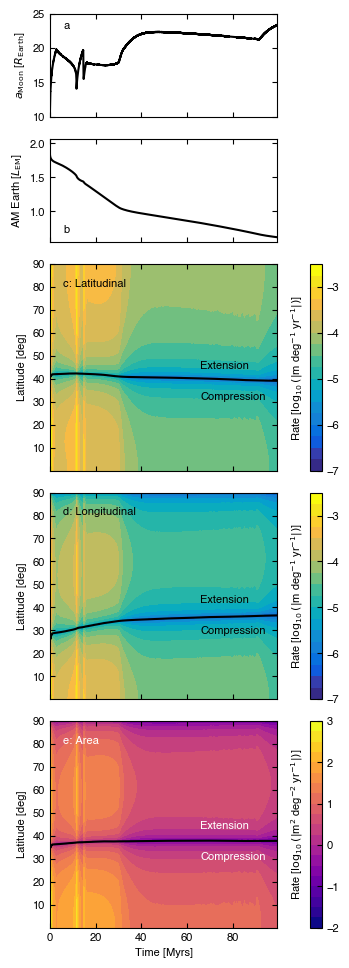

In [15]:
print('begin')

#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure8.pdf')
mpl.pyplot.close(fig)

###########################################################################################
###########################################################################################
###########################################################################################
#plot the single column figure

#initialise the figure
fig = plt.figure(figsize=(3.5,9.724))
gs = gridspec.GridSpec(5, 2,
                      width_ratios=[1,0.05],
                      height_ratios=[0.5,0.5,1,1,1])
ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[2], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[4], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[6], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[8], sharex=ax[0][0]))

ax_col=[[]]
ax_col[0].append(plt.subplot(gs[5]))
ax_col[0].append(plt.subplot(gs[7]))
ax_col[0].append(plt.subplot(gs[9]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)


ax[0][0].plot(Ctime/1E6, Ca, 'k-', linewidth=1.5)

ax[0][1].plot(Ctime/1E6, CL/LEM, 'k-', linewidth=1.5)


ax[0][0].set_ylim([10,25])
    
lat_contours=np.linspace(-7,-2.5,18+1)
lon_contours=np.linspace(-7,-2.5,18+1)

lat_labels=np.asarray([-7,-6,-5,-4,-3])
lon_labels=np.asarray([-7,-6,-5,-4,-3])

#to be same as canonical
lat_contours=np.linspace(-7,-2.5,18+1)
lon_contours=np.linspace(-7,-2.5,18+1)
Acontours=np.linspace(-2,3,20+1)

lat_labels=np.asarray([-7,-6,-5,-4,-3])
lon_labels=np.asarray([-7,-6,-5,-4,-3])
Alabels=np.asarray([-2,-1,0,1,2,3])

# contour1 = ax[0][2].contourf(LLL, TTT, np.log10(np.absolute(DLAT)), levels=lat_contours, cmap=cmaps.parula)
contour1 = ax[0][2].contourf(LLL, TTT, np.log10(np.absolute(DLAT)+1E-16), levels=lat_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lat_contours)-1)))
contour10 = ax[0][2].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[0.0], colors=['k'], linestyles='solid')
contour2 = ax[0][3].contourf(LLL, TTT, np.log10(np.absolute(DLON)+1E-16), levels=lon_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lon_contours)-1)))
contour20 = ax[0][3].contour(LLL, TTT, DLON, linewidth=1.5, levels=[0.0], colors=['k'],linestyles='solid')
contour3 = ax[0][4].contourf(LLL, TTT, np.log10(np.absolute(AAA)+1E-16), levels=Acontours, colors=cm.plasma(np.linspace(0, 1, np.size(Acontours)-1)))
contour30 = ax[0][4].contour(LLL, TTT, AAA, linewidth=1.5, levels=[0], colors=['k'], linestyles='solid')

for contour in [contour1, contour2, contour3]:
    if contour is not None and hasattr(contour, 'collections') and len(contour.collections) > 0:
        for c in contour.collections:
            c.set_rasterized(True)
    else:
        print(contour, "contour missing")

ax[0][0].set_ylabel(r"$a_{\rm Moon}$ [$R_{\rm Earth}$]")
ax[0][1].set_ylabel(r"AM Earth [$L_{\rm EM}$]")
ax[0][2].set_ylabel("Latitude [deg]")
ax[0][3].set_ylabel("Latitude [deg]")
ax[0][4].set_ylabel("Latitude [deg]")
ax[0][4].set_xlabel(r"Time [Myrs]")

for i in np.arange(5):
    if i!=4: plt.setp( ax[0][i].get_xticklabels(), visible=False)
    ax[0][i].tick_params(direction="in", top=True, right=True)

ax[0][0].set_xlim([0, np.amax(time)/1E6])
ax[0][1].set_xlim([0, np.amax(time)/1E6])
ax[0][2].set_xlim([0, np.amax(time)/1E6])
ax[0][3].set_xlim([0, np.amax(time)/1E6])
ax[0][4].set_xlim([0, np.amax(time)/1E6])


#label axis
ax[0][0].text(0.06, 0.93, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.06, 0.07, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.06, 0.93, 'c: Latitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.06, 0.93, 'd: Longitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][4].text(0.06, 0.93, 'e: Area', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][4].transAxes, color='w')


zero_paths1 = contour10.collections[0].get_paths()
ax[0][2].text(0.66, zero_paths1[0].vertices[-1,1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][2].text(0.66, zero_paths1[0].vertices[-1,1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
zero_paths2 = contour20.collections[0].get_paths()
ax[0][3].text(0.66, zero_paths2[0].vertices[-1,1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][3].text(0.66, zero_paths2[0].vertices[-1,1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')
zero_paths3 = contour30.collections[0].get_paths()
ax[0][4].text(0.66, zero_paths3[0].vertices[-1,1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][4].transAxes, color='w')
ax[0][4].text(0.66, zero_paths3[0].vertices[-1,1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][4].transAxes, color='w')


cbar1=plt.colorbar(contour1, cax=ax_col[0][0], orientation='vertical',ticks=lat_labels)
cbar2=plt.colorbar(contour2, cax=ax_col[0][1], orientation='vertical',ticks=lon_labels)
cbar3=plt.colorbar(contour3, cax=ax_col[0][2], orientation='vertical',ticks=Alabels)


cbar1.set_label(r'Rate [$\log_{10} (|$m deg$^{-1}$ yr$^{-1}$$|)$]', labelpad=-36)
cbar2.set_label(r'Rate [$\log_{10} (|$m deg$^{-1}$ yr$^{-1}$$|)$]', labelpad=-36)
cbar3.set_label(r'Rate [$\log_{10} (|$m$^2$ deg$^{-2}$ yr$^{-1}$$|)$]', labelpad=-36)

for i in np.arange(3):
    ax_col[0][i].tick_params(direction="in")

fig.tight_layout()
plt.savefig('Figure8.pdf')
    
print('done')

## Figure S1 and equivilant to Figure 8

### Load in data

In [16]:
#Figure 3 or 7 data
dir=data_dir+'/rev8e3_for_simon'
dirnames_const=['rev8a','rev8b', 'rev8c','']

Nruns_const=np.size(dirnames_const)

#########################
#read in the constant path
Ctime_const=[]
Ctime_high_const=[]
Ca_const=[]
Cob_const=[]
Comg_const=[]
CL_const=[]
Ce_const=[]
Ci_const=[]

for k in np.arange(np.size(dirnames_const)):
    
    ###Semi-major axis, e, i
    Cuk_f=open(dir+'/'+dirnames_const[k]+'/moon101.out', 'r')

    #extract the lines and strip them of any new lines etc.
    reader = csv.reader(Cuk_f, delimiter=" ", skipinitialspace=True)
    temp = list(reader)

    for i in np.arange(len(temp)):
        
        if (np.size(temp[i])>3):
            
            Ctime_const.append(temp[i][0]) #time
            Ca_const.append(temp[i][1]) #semi-major axis
            Ce_const.append(temp[i][2]) #eccentricity
            Ci_const.append(temp[i][3])
        

    ###obliquity
    Cuk_f=open(dir+'/'+dirnames_const[k]+'/pole.out', 'r')

    #extract the lines and strip them of any new lines etc.
    reader = csv.reader(Cuk_f, delimiter=" ", skipinitialspace=True)
    temp = list(reader)

    for i in np.arange(len(temp)):
        if np.size(temp[i])>4:
            Cob_const.append(temp[i][1]) #obliquity
            Comg_const.append(temp[i][3]) #rotation rate
            


#convert to useful type and unit
Ctime_const=np.asarray(Ctime_const, dtype=np.float64)
Ca_const=np.asarray(Ca_const, dtype=np.float64)
Cob_const=np.asarray(Cob_const, dtype=np.float64)
Ce_const=np.asarray(Ce_const, dtype=np.float64)
Ci_const=np.asarray(Ci_const, dtype=np.float64)
Comg_const=np.asarray(Comg_const, dtype=np.float64)/const.year
CL_const=Comg_const*C_Earth*MEarth*(REarth**2)

#remove any repeat values
temp=(Ctime_const[1:]-Ctime_const[:-1])
ind=np.where(temp==0.0)[0]
Ctime_const=np.delete(Ctime_const,ind+1)
Ca_const=np.delete(Ca_const,ind+1)
Cob_const=np.delete(Cob_const,ind+1)
Ce_const=np.delete(Ce_const,ind+1)
Ci_const=np.delete(Ci_const,ind+1)
Comg_const=np.delete(Comg_const,ind+1)
CL_const=np.delete(CL_const,ind+1)

#change names to be consistent with rest of program
Ctime=Ctime_const
Ca=Ca_const
Cob=Cob_const
Ce=Ce_const
Ci=Ci_const

Comg=Comg_const
CL=CL_const

    

print('done')

done


In [17]:
import numpy as np
import h5py

# --------------------------------------------------
# User inputs
# --------------------------------------------------
hdf5_file = dir_additional_data+"/Cuk21_surf_change_CukFig3_delta.h5"

# --------------------------------------------------
# Open HDF5 file
# --------------------------------------------------
with h5py.File(hdf5_file, "r") as h5:

    Nmu = h5.attrs["Nmu"]
    Nt  = h5.attrs["Nt"]
    Ntmax     = None # optional limit on number of timesteps
    if Ntmax is not None:
        Nt = min(Nt, Ntmax)

    print(f"Nmu = {Nmu}, Nt = {Nt}")

    # --------------------------------------------------
    # Load time and dL_dt
    # --------------------------------------------------
    steps = np.arange(Nt)
    time  = h5["time"][:Nt]
    dLdt = h5["dL_dt"][:Nt]

    # --------------------------------------------------
    # Precompute cumulative sums of delta fields
    # --------------------------------------------------
    names = ["dl_lat", "dl_lon", "dA",
             "ddl_lat_dL", "ddl_lon_dL", "ddA_dL"]

    cum_delta = {}
    for name in names:
        cum_delta[name] = np.cumsum(h5["delta"][name][:Nt, :], axis=0)

    # --------------------------------------------------
    # Reconstruct full arrays (similar to your binary reshaping)
    # --------------------------------------------------
    dl_lat      = cum_delta["dl_lat"]
    dl_lon      = cum_delta["dl_lon"]
    dA          = cum_delta["dA"]
    ddl_lat_dL  = cum_delta["ddl_lat_dL"]
    ddl_lon_dL  = cum_delta["ddl_lon_dL"]
    ddA_dL      = cum_delta["ddA_dL"]

    # Compute _dt fields from delta and dL_dt
    ddl_lat_dt  = ddl_lat_dL * dLdt[:, np.newaxis]
    ddl_lon_dt  = ddl_lon_dL * dLdt[:, np.newaxis]
    ddA_dt      = ddA_dL * dLdt[:, np.newaxis]


print("Data successfully loaded from HDF5!")


Nmu = 1000, Nt = 160294
Data successfully loaded from HDF5!


### Plot Figure S1

done


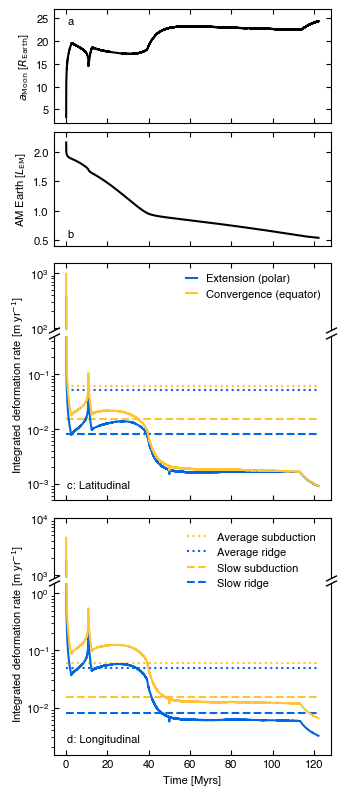

In [18]:
#plot the maximum and minimum deformation rates as a function of time
#Figure 7 or S1

#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('FigureS1.pdf')
mpl.pyplot.close(fig)



yrange=np.asarray([[[0.91E2,1.5E3],[5E-4,0.49]],
        [[0.905E3,1E4],[1.5E-3,1.5]]])

hratio=np.empty(2)
for i in np.arange(2):
    hratio[i]=(np.log10(yrange[i,0,1])-np.log10(yrange[i,0,0]))/(np.log10(yrange[i,1,1])-np.log10(yrange[i,1,0]))

#initialise the figure
fig = plt.figure(figsize=(3.5,8.0))

gs0 = gridspec.GridSpec(3, 1,
                        width_ratios=[1],
                        height_ratios=[1,1,1],
                        )

gs000 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=gs0[0],
                                        height_ratios=[1,1],
#                                         hspace=0.05,
#                                         wspace=0.05
                                        )

gs00 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=gs0[1],
                                        height_ratios=[hratio[0],1],
                                        hspace=0.05,
                                        wspace=0.05
                                        )
gs01 = gridspec.GridSpecFromSubplotSpec(2, 1, 
                                        subplot_spec=gs0[2],
                                        height_ratios=[hratio[1],1],
                                        hspace=0.05,
                                        wspace=0.05
                                        )

ax=[[],[],[]]


ax[0].append(plt.subplot(gs00[0]))
ax[0].append(plt.subplot(gs00[1], sharex=ax[0][0]))

ax[1].append(plt.subplot(gs01[0], sharex=ax[0][0]))
ax[1].append(plt.subplot(gs01[1], sharex=ax[0][0]))

ax[2].append(plt.subplot(gs000[0], sharex=ax[0][0]))
ax[2].append(plt.subplot(gs000[1], sharex=ax[0][0]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)

col=cmaps.parula([0.15,0.85])


ax[2][0].plot(Ctime/1E6, Ca, 'k-', linewidth=1.5)
ax[2][1].plot(Ctime/1E6, CL/LEM, 'k-', linewidth=1.5)
ax[2][0].set_ylim([2,27])

ax[2][1].set_ylim([0.4,2.35])



ddl_lat_dt_max=np.zeros(np.size(time))*np.nan
ddl_lat_dt_min=np.zeros(np.size(time))*np.nan

ddl_lon_dt_max=np.zeros(np.size(time))*np.nan
ddl_lon_dt_min=np.zeros(np.size(time))*np.nan

ind_max=np.size(time)-1
ind_min=0#np.where(time>1E5)[0][0]
for i in np.arange(ind_min,ind_max):
    #longitudinal is easy. Accomodated around minor circle
    ddl_lon_dt_max[i]=np.amax(ddl_lon_dt[i,:])*2*np.pi
    ddl_lon_dt_min[i]=np.amin(ddl_lon_dt[i,:])*2*np.pi
    
    
    #latitudinal is harder. Need to integrate over surface
    temp=np.where(ddl_lat_dt[i,:]<0)[0][-1]
    
    #print(lat[0:temp])
    ddl_lat_dt_min[i]=2*integrate.trapz(ddl_lat_dt[i,0:temp]*np.pi/180.0,90.0-lat[0:temp])
    ddl_lat_dt_max[i]=integrate.trapz(ddl_lat_dt[i,(temp+1):]*np.pi/180.0,90.0-lat[(temp+1):])

ax[0][1].plot([0,time[ind_max]/1E6],[8E-3,8E-3],'--', color=col[0],linewidth=1.5) #slow mid ocean ridge
ax[0][1].plot([0,time[ind_max]/1E6],[15E-3,15E-3],'--', color=col[1],linewidth=1.5) #slow subduction
ax[0][1].plot([0,time[ind_max]/1E6],[50E-3,50E-3],':', color=col[0],linewidth=1.5) #average mid-ocean ridge
ax[0][1].plot([0,time[ind_max]/1E6],[60E-3,60E-3],':', color=col[1],linewidth=1.5) #avererage subduction


ax[1][1].plot([0,time[ind_max]/1E6],[60E-3,60E-3],':', color=col[1],linewidth=1.5, label='Average subduction') #avererage subduction
ax[1][1].plot([0,time[ind_max]/1E6],[50E-3,50E-3],':', color=col[0],linewidth=1.5, label='Average ridge') #average mid-ocean ridge
ax[1][1].plot([0,time[ind_max]/1E6],[15E-3,15E-3],'--', color=col[1],linewidth=1.5, label='Slow subduction') #slow subduction
ax[1][1].plot([0,time[ind_max]/1E6],[8E-3,8E-3],'--', color=col[0],linewidth=1.5, label='Slow ridge') #slow mid ocean ridge

    
ax[0][0].plot(time/1E6, np.absolute(ddl_lat_dt_max),'-', color=col[0],linewidth=1.5,label='Extension (polar)')
ax[0][0].plot(time/1E6, np.absolute(ddl_lat_dt_min),'-', color=col[1],linewidth=1.5,label='Convergence (equator)')
ax[0][1].plot(time/1E6, np.absolute(ddl_lat_dt_max),'-', color=col[0],linewidth=1.5)
ax[0][1].plot(time/1E6, np.absolute(ddl_lat_dt_min),'-', color=col[1],linewidth=1.5)


ax[1][0].plot(time/1E6, np.absolute(ddl_lon_dt_max),'-', color=col[0],linewidth=1.5)
ax[1][0].plot(time/1E6, np.absolute(ddl_lon_dt_min),'-', color=col[1],linewidth=1.5)
ax[1][1].plot(time/1E6, np.absolute(ddl_lon_dt_max),'-', color=col[0],linewidth=1.5)
ax[1][1].plot(time/1E6, np.absolute(ddl_lon_dt_min),'-', color=col[1],linewidth=1.5)


ax[0][0].set_yscale('log')
ax[0][1].set_yscale('log')
ax[1][0].set_yscale('log')
ax[1][1].set_yscale('log')

################
#Do funky things with split axes
ax[0][0].set_ylim(yrange[0,0,:])
ax[0][1].set_ylim(yrange[0,1,:])


ax[0][0].spines['bottom'].set_visible(False)
ax[0][1].spines['top'].set_visible(False)
ax[0][0].xaxis.tick_top()
ax[0][0].tick_params(labeltop=False)  # don't put tick labels at the top
ax[0][1].xaxis.tick_bottom()

d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=8,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax[0][0].plot([0, 1], [0, 0], transform=ax[0][0].transAxes, **kwargs)
ax[0][1].plot([0, 1], [1, 1], transform=ax[0][1].transAxes, **kwargs)

##############
ax[1][0].set_ylim(yrange[1,0,:])
ax[1][1].set_ylim(yrange[1,1,:])

ax[1][0].spines['bottom'].set_visible(False)
ax[1][1].spines['top'].set_visible(False)
ax[1][0].xaxis.tick_top()
ax[1][0].tick_params(labeltop=False)  # don't put tick labels at the top
ax[1][1].xaxis.tick_bottom()


d = .5  # proportion of vertical to horizontal extent of the slanted line
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=8,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax[1][0].plot([0, 1], [0, 0], transform=ax[1][0].transAxes, **kwargs)
ax[1][1].plot([0, 1], [1, 1], transform=ax[1][1].transAxes, **kwargs)


ax[2][0].set_ylabel(r"$a_{\rm Moon}$ [$R_{\rm Earth}$]")
ax[2][1].set_ylabel(r"AM Earth [$L_{\rm EM}$]")

ax[0][1].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')
ax[1][1].set_ylabel('Integrated deformation rate [m yr$^{-1}$]')
ax[0][1].yaxis.set_label_coords(-0.1, 0.71)
ax[1][1].yaxis.set_label_coords(-0.1, 0.71)

ax[1][1].set_xlabel('Time [Myrs]')

plt.setp( ax[2][0].get_xticklabels(), visible=False)
plt.setp( ax[2][1].get_xticklabels(), visible=False)
plt.setp( ax[0][1].get_xticklabels(), visible=False)

ax[2][0].tick_params(direction="in", top=True, right=True)
ax[2][1].tick_params(direction="in", top=True, right=True)
ax[0][0].tick_params(direction="in", top=True)
ax[0][1].tick_params(direction="in")
ax[1][0].tick_params(direction="in", top=True)
ax[1][1].tick_params(direction="in")

ax[0][0].legend(frameon=False, handlelength=1.0, loc='upper right')
ax[1][1].legend(frameon=False, handlelength=1.9, loc='upper right',bbox_to_anchor=(0.98, 1.36))

ax[2][0].text(0.05, 0.94, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[2][0].transAxes, color='k')
ax[2][1].text(0.05, 0.06, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[2][1].transAxes, color='k')
  
ax[0][1].text(0.05, 0.06, 'c: Latitudinal', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[1][1].text(0.05, 0.06, 'd: Longitudinal', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[1][1].transAxes, color='k')
       


fig.tight_layout()
plt.savefig('FigureS1.pdf')

print('done')

### Downsample data for interpolating contours

In [19]:
#downsample the data for the contour plots and compare to the full data set
#there are a number of options

dLdt_full=gradient2(Ctime,CL)


#function to find the turning points - key points in the function that we do not want to ignore
def find_turning_points(x,y,xpoints_min,xpoints_max,bin_min,bin_max):
    
    ind_min=np.empty(np.size(xpoints_min),dtype=int)
    for i,xmid in enumerate(xpoints_min):
        temp=np.where((x>=(np.amax([np.amin(x),xmid-bin_min])))&(x<=(np.amin([np.amax(x),xmid+bin_min]))))[0]
        temp2=np.argsort(y[temp])
        ind_min[i]=temp[temp2[0]]
        
    ind_max=np.empty(np.size(xpoints_max),dtype=int)
    for i,xmid in enumerate(xpoints_max):
        temp=np.where((x>=(np.amax([np.amin(x),xmid-bin_max])))&(x<=(np.amin([np.amax(x),xmid+bin_max]))))[0]
        temp2=np.argsort(y[temp])
        ind_max[i]=temp[temp2[-1]]
        
    
    return ind_min, ind_max
    
#We also want to ignore a blip that can cause some issues with the contour maps
(temp,temp2)=find_turning_points(Ctime,dLdt_full,[50E6],[],2E6,2E6)
ind_plot=np.append(np.arange(0,temp[0]),np.arange(temp[0]+2,np.size(Ctime))) #ignore a troublesome blip
(ind_min, ind_max)=find_turning_points(Ctime,dLdt_full,[0,12E6,16E6],[2E6,15E6],2E6,2E6)

print('done')

done


In [20]:
#define timesteps based on the number of contours
Nskip='Ncont'
# Nstep_plot=Ncont*(Ncont+1)+1
Nstep_plot=Ncont*2+1
tstep_plot=Ctime[-1]/Nstep_plot/1E6

time=np.arange(0.0,np.amax(Ctime),tstep_plot*1E6)
temp=np.where(time<np.amin(Ctime))[0]
if np.size(temp)!=0:
    time=time[(temp[-1]+1):]

dLdt_full=gradient2(Ctime,CL)


fdLdt = interp1d(Ctime, dLdt_full, kind='linear')
dLdt=fdLdt(time)

dLdt[0]=dLdt_full[0]
for i in ind_min[1:]:
    temp=np.where(time>Ctime[i])[0][0]
    print(temp)
    time=np.concatenate((time[0:temp],[Ctime[i]],time[temp:]))
    dLdt=np.concatenate((dLdt[0:temp],[dLdt_full[i]],dLdt[temp:]))
for i in ind_max:
    temp=np.where(time>Ctime[i])[0][0]
    time=np.concatenate((time[0:temp],[Ctime[i]],time[temp:]))
    dLdt=np.concatenate((dLdt[0:temp],[dLdt_full[i]],dLdt[temp:]))
    
steps_ds=np.zeros(np.size(dLdt),dtype=int)
for i,t in enumerate(time):
    temp=np.where(Ctime>t)[0][0]
    steps_ds[i]=temp
    

print('done')

18
31
done


### Interpolate data to make meshgrid to plot contours

In [21]:
print('begin')

Nt=np.size(Ctime)
steps_cont=steps_ds
time_cont=Ctime[steps_cont]

ddl_lon_dt_cont=ddl_lon_dt[steps_cont]
ddl_lat_dt_cont=ddl_lat_dt[steps_cont]
ddA_dt_cont=ddA_dt[steps_cont]

#calculate the interpolation hulls
lat_grid=np.flipud(lat)#np.linspace(0, 90, Ncont*(Ncont+1))
t_grid=np.linspace(np.amin(time_cont), np.amax(time_cont),Ncont*2+1)/1E6

for i in ind_min[1:]:
    temp=np.where(t_grid>Ctime[i]/1E6)[0][0]
    t_grid=np.concatenate((t_grid[0:temp],[Ctime[i]/1E6],t_grid[temp:]))
for i in ind_max:
    temp=np.where(t_grid>Ctime[i]/1E6)[0][0]
    t_grid=np.concatenate((t_grid[0:temp],[Ctime[i]/1E6],t_grid[temp:]))

LLL, TTT = np.meshgrid(t_grid, lat_grid)

temp=np.ones(np.shape(ddl_lat_dt_cont))
time_arr=temp*time_cont[:, None]
lat_arr=temp*lat[None,:]

DLON=griddata(((time_arr.flatten()/1E6,90.0-lat_arr.flatten())),ddl_lon_dt_cont.flatten()*np.pi/180.0,(LLL,TTT))#, method='linear')
DLAT=griddata(((time_arr.flatten()/1E6,90.0-lat_arr.flatten())),ddl_lat_dt_cont.flatten()*np.pi/180.0,(LLL,TTT))#, method='linear')
AAA=griddata(((time_arr.flatten()/1E6,90.0-lat_arr.flatten())),ddA_dt_cont.flatten()*(np.pi/180.0)**2,(LLL,TTT))#, method='linear')
 

print('done')

begin
done


### Plot the equivilant for Figure 8

begin


/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_390/2083796161.py:69: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour10 = ax[0][2].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[0.0], colors=['k'], linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_390/2083796161.py:71: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour20 = ax[0][3].contour(LLL, TTT, DLON, linewidth=1.5, levels=[0.0], colors=['k'],linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_390/2083796161.py:73: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour30 = ax[0][4].contour(LLL, TTT, AAA, linewidth=1.5, levels=[0], colors=['k'], linestyles='solid')
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_390/2083796161.py:75: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.

done


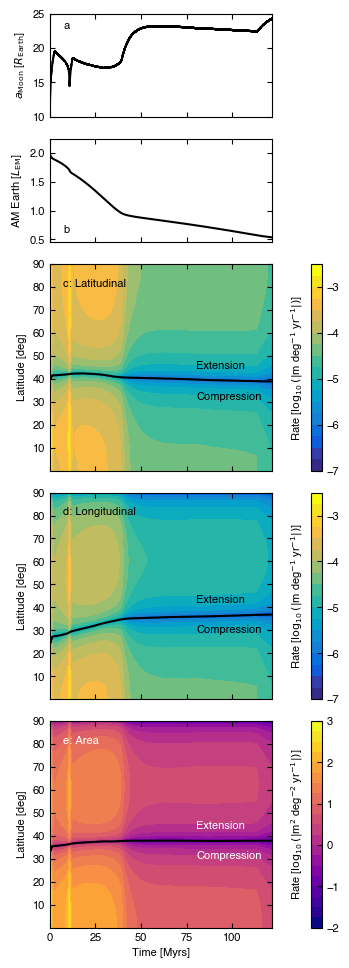

In [22]:
print('begin')

#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(3.9,6.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure8_equivilant_for_FigureS1_case.pdf')
mpl.pyplot.close(fig)

###########################################################################################
###########################################################################################
###########################################################################################
#plot the single column figure

#initialise the figure
fig = plt.figure(figsize=(3.5,9.724))
gs = gridspec.GridSpec(5, 2,
                      width_ratios=[1,0.05],
                      height_ratios=[0.5,0.5,1,1,1])
ax=[[]]
ax[0].append(plt.subplot(gs[0]))
ax[0].append(plt.subplot(gs[2], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[4], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[6], sharex=ax[0][0]))
ax[0].append(plt.subplot(gs[8], sharex=ax[0][0]))

ax_col=[[]]
ax_col[0].append(plt.subplot(gs[5]))
ax_col[0].append(plt.subplot(gs[7]))
ax_col[0].append(plt.subplot(gs[9]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)


ax[0][0].plot(Ctime/1E6, Ca, 'k-', linewidth=1.5)

ax[0][1].plot(Ctime/1E6, CL/LEM, 'k-', linewidth=1.5)


ax[0][0].set_ylim([10,25])
    
lat_contours=np.linspace(-7,-2.5,18+1)
lon_contours=np.linspace(-7,-2.5,18+1)

lat_labels=np.asarray([-7,-6,-5,-4,-3])
lon_labels=np.asarray([-7,-6,-5,-4,-3])

#to be same as canonical
lat_contours=np.linspace(-7,-2.5,18+1)
lon_contours=np.linspace(-7,-2.5,18+1)
Acontours=np.linspace(-2,3,20+1)

lat_labels=np.asarray([-7,-6,-5,-4,-3])
lon_labels=np.asarray([-7,-6,-5,-4,-3])
Alabels=np.asarray([-2,-1,0,1,2,3])

contour1 = ax[0][2].contourf(LLL, TTT, np.log10(np.absolute(DLAT)), levels=lat_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lat_contours)-1)))
contour10 = ax[0][2].contour(LLL, TTT, DLAT, linewidth=1.5, levels=[0.0], colors=['k'], linestyles='solid')
contour2 = ax[0][3].contourf(LLL, TTT, np.log10(np.absolute(DLON)), levels=lon_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lon_contours)-1)))
contour20 = ax[0][3].contour(LLL, TTT, DLON, linewidth=1.5, levels=[0.0], colors=['k'],linestyles='solid')
contour3 = ax[0][4].contourf(LLL, TTT, np.log10(np.absolute(AAA)), levels=Acontours, colors=cm.plasma(np.linspace(0, 1, np.size(Acontours)-1)))
contour30 = ax[0][4].contour(LLL, TTT, AAA, linewidth=1.5, levels=[0], colors=['k'], linestyles='solid')

for c in contour1.collections:
    c.set_rasterized(True)

for c in contour2.collections:
    c.set_rasterized(True)

for c in contour3.collections:
    c.set_rasterized(True)

ax[0][0].set_ylabel(r"$a_{\rm Moon}$ [$R_{\rm Earth}$]")
ax[0][1].set_ylabel(r"AM Earth [$L_{\rm EM}$]")
ax[0][2].set_ylabel("Latitude [deg]")
ax[0][3].set_ylabel("Latitude [deg]")
ax[0][4].set_ylabel("Latitude [deg]")
ax[0][4].set_xlabel(r"Time [Myrs]")

for i in np.arange(5):
    if i!=4: plt.setp( ax[0][i].get_xticklabels(), visible=False)
    ax[0][i].tick_params(direction="in", top=True, right=True)

ax[0][0].set_xlim([0, np.amax(time)/1E6])
ax[0][1].set_xlim([0, np.amax(time)/1E6])
ax[0][2].set_xlim([0, np.amax(time)/1E6])
ax[0][3].set_xlim([0, np.amax(time)/1E6])
ax[0][4].set_xlim([0, np.amax(time)/1E6])


#label axis
ax[0][0].text(0.06, 0.93, 'a', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.06, 0.07, 'b', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.06, 0.93, 'c: Latitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][3].text(0.06, 0.93, 'd: Longitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][4].text(0.06, 0.93, 'e: Area', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][4].transAxes, color='w')


zero_paths1 = contour10.collections[0].get_paths()
ax[0][2].text(0.66, zero_paths1[0].vertices[-1,1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][2].transAxes, color='k')
ax[0][2].text(0.66, zero_paths1[0].vertices[-1,1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')
zero_paths2 = contour20.collections[0].get_paths()
ax[0][3].text(0.66, zero_paths2[0].vertices[-1,1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][3].transAxes, color='k')
ax[0][3].text(0.66, zero_paths2[0].vertices[-1,1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][3].transAxes, color='k')
zero_paths3 = contour30.collections[0].get_paths()
ax[0][4].text(0.66, zero_paths3[0].vertices[-1,1]/90+0.05, 'Extension', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][4].transAxes, color='w')
ax[0][4].text(0.66, zero_paths3[0].vertices[-1,1]/90-0.05, 'Compression', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][4].transAxes, color='w')


cbar1=plt.colorbar(contour1, cax=ax_col[0][0], orientation='vertical',ticks=lat_labels)
cbar2=plt.colorbar(contour2, cax=ax_col[0][1], orientation='vertical',ticks=lon_labels)
cbar3=plt.colorbar(contour3, cax=ax_col[0][2], orientation='vertical',ticks=Alabels)


cbar1.set_label(r'Rate [$\log_{10} (|$m deg$^{-1}$ yr$^{-1}$$|)$]', labelpad=-36)
cbar2.set_label(r'Rate [$\log_{10} (|$m deg$^{-1}$ yr$^{-1}$$|)$]', labelpad=-36)
cbar3.set_label(r'Rate [$\log_{10} (|$m$^2$ deg$^{-2}$ yr$^{-1}$$|)$]', labelpad=-36)

for i in np.arange(3):
    ax_col[0][i].tick_params(direction="in")

fig.tight_layout()
plt.savefig('Figure8_equivilant_for_FigureS1_case.pdf')
    
print('done')